# 00 · Feature Drift EDA — year-over-year drift that confounds the SFP scrap signal

**Why this notebook exists.** In `verify_sfp_oracle.py` the *true* total-loss (oracle)
base rate is **not constant across the OOT windows**: it is ≈16.6% at v1's 2021 window but
≈22.1% at the 2024 windows. That matters because the headline SFP symptom is *scrap-rate
inflation* (v1 ~12.5% → v2a ~18.4% → v3a ~18.6%). If the **true** total-loss rate is itself
drifting upward over calendar time, then part of that scrap inflation is genuine — **not** the
self-fulfilling-prophecy loop. This is a *measurement confound* (cf. `problem.md` §2.5 #6/#8/#10):
we must know how much of the scrap rise is real base-rate drift vs. SFP amplification.

**This notebook is analysis only — it does not modify any generator code.** It (1) confirms the
drift, (2) traces it to its root feature, and (3) traces that feature to the data-generating
process, so the confound is understood and can be separated from the loop.

> Take-away up front: the drift is driven by **`repair_to_value_ratio` (rtv) rising over the
> years**, which is in turn driven by **vehicle value falling as the simulated fleet ages** —
> and the ageing is a DGP artifact of a **fixed `manufacture_year` floor of 2004**. It is a
> generation artifact, *separate from the SFP loop*.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the freshly generated dataset (run.py writes to generate/parquet).
CANDS = [
    Path.cwd() / "../src/data/synthetic/generate/parquet/claims_all.parquet",
    Path.cwd() / "src/data/synthetic/generate/parquet/claims_all.parquet",
    Path.cwd() / "../src/data/synthetic/parquet/claims_all.parquet",
]
DATA = next(p.resolve() for p in CANDS if p.exists())
SYNTH_DIR = DATA.parents[2]          # .../src/data/synthetic  (holds the `generate` package)

df = pd.read_parquet(DATA)
df["year"] = pd.to_datetime(df["claim_date"]).dt.year
print("loaded", DATA)
print(len(df), "rows,", df["year"].min(), "-", df["year"].max())


loaded /Users/yeon/work/uob/uob-final-dissertation-allianz-internship-2026/src/data/synthetic/generate/parquet/claims_all.parquet
70000 rows, 2016 - 2024


## 1 · Confirm the drift — true (oracle) total-loss rate by calendar year

`garage_outcome` (the oracle Y) is intentionally **never persisted** to the shared datasets
(oracle-free by construction). But generation is deterministic, so we can re-run it in memory
here — purely for this diagnostic — and read the true total-loss rate per year.


In [2]:
sys.path.insert(0, str(SYNTH_DIR))
from generate.base_features import generate_base_features
from generate.enrichment import build_enrichment_table, join_enrichment
from generate.pre_ml import generate_pre_ml_era
from generate.config import SEED

rng = np.random.default_rng(SEED)
d2 = generate_base_features()
d2 = join_enrichment(d2, build_enrichment_table())
d2, oracle = generate_pre_ml_era(d2, rng)
d2["year"] = pd.to_datetime(d2["claim_date"]).dt.year
d2["oracle_TL"] = oracle.values

true_by_year = d2.groupby("year")["oracle_TL"].mean()
print("true (oracle) total-loss rate by claim year:")
print((true_by_year * 100).round(1).astype(str) + "%")


true (oracle) total-loss rate by claim year:
year
2016    10.1%
2017    11.5%
2018    13.2%
2019    15.6%
2020    17.6%
2021    16.8%
2022    16.6%
2023    18.4%
2024    21.5%
Name: oracle_TL, dtype: object


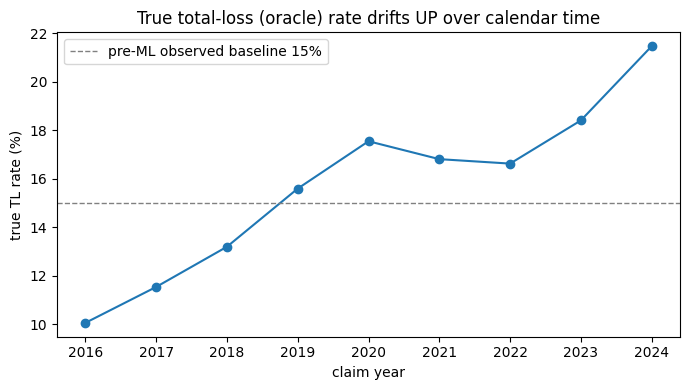

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(true_by_year.index, true_by_year.values * 100, "o-")
ax.axhline(15, ls="--", c="grey", lw=1, label="pre-ML observed baseline 15%")
ax.set_title("True total-loss (oracle) rate drifts UP over calendar time")
ax.set_xlabel("claim year"); ax.set_ylabel("true TL rate (%)"); ax.legend()
plt.tight_layout(); plt.show()


The true rate climbs from ~14% (2016) to ~22% (2024). Since the oracle is a **fixed function
of features**, a rising true rate means **the feature distribution itself is drifting**. Which
feature?


## 2 · Find the driver — oracle inputs by year

The oracle log-odds are dominated by `repair_to_value_ratio` (rtv): a car with rtv ≥ 1.0
(repair cost ≥ market value) is a near-certain write-off. Track every oracle input by year.


In [4]:
g = df.groupby("year")
by_year = pd.DataFrame({
    "n":         g.size(),
    "rtv_mean":  g["repair_to_value_ratio"].mean(),
    "rtv_ge_1":  g["repair_to_value_ratio"].apply(lambda s: (s >= 1.0).mean()),
    "severe":    g["damage_severity"].apply(lambda s: (s == "severe").mean()),
    "multiple":  g["damage_location"].apply(lambda s: (s == "multiple").mean()),
    "age_mean":  g["vehicle_age_years"].mean(),
    "veh_value": g["vehicle_value"].mean(),
    "ucpi":      g["used_car_price_index"].mean(),
    "v2a_score": g["model_v2a_score"].mean(),
}).round(3)
by_year


,n,rtv_mean,rtv_ge_1,severe,multiple,age_mean,veh_value,ucpi,v2a_score
year,,,,,,,,,
2016,7760,0.238,0.040,0.197,0.203,5.104,16696.637,1.00,0.095
2017,7622,0.271,0.059,0.194,0.192,5.637,16006.162,1.02,0.116
2018,7885,0.294,0.073,0.189,0.197,6.060,15512.716,1.03,0.129
2019,7699,0.333,0.092,0.205,0.198,6.492,15228.504,1.05,0.151
2020,7857,0.381,0.113,0.194,0.195,7.008,13359.402,0.97,0.175
2021,7952,0.352,0.100,0.200,0.200,7.565,15346.248,1.18,0.163
2022,7709,0.347,0.101,0.202,0.196,8.063,15983.209,1.28,0.170
2023,7626,0.386,0.115,0.201,0.195,8.442,14252.913,1.18,0.186
2024,7890,0.438,0.142,0.207,0.196,8.978,12754.253,1.10,0.213


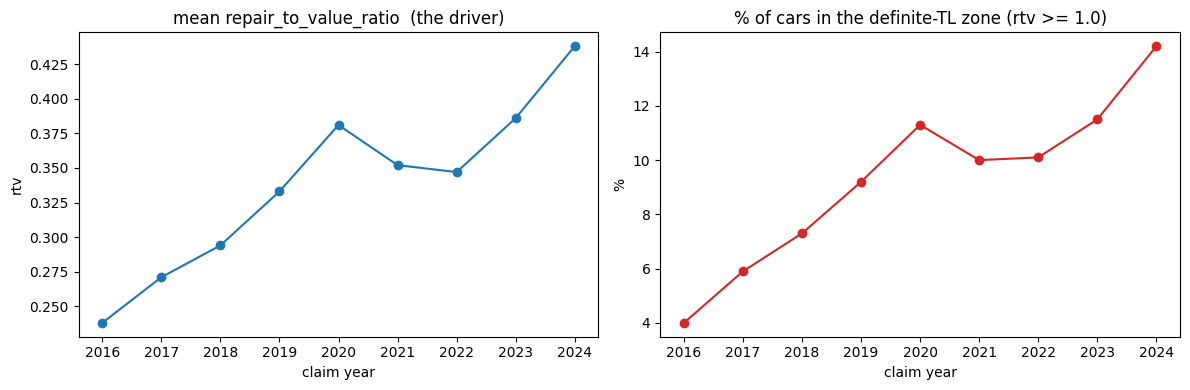

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(by_year.index, by_year["rtv_mean"], "o-")
ax[0].set_title("mean repair_to_value_ratio  (the driver)")
ax[0].set_xlabel("claim year"); ax[0].set_ylabel("rtv")
ax[1].plot(by_year.index, by_year["rtv_ge_1"] * 100, "o-", color="C3")
ax[1].set_title("% of cars in the definite-TL zone (rtv >= 1.0)")
ax[1].set_xlabel("claim year"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()


`rtv_mean` rises 0.24 → 0.44 and the **`rtv >= 1.0` share nearly quadruples (4% → 14%)** —
that alone explains the rising true-TL rate. `damage_severity`/`damage_location` are flat, so
they are *not* the cause. Now: why is rtv drifting up? rtv = repair_estimate / **vehicle_value**,
so a falling `veh_value` inflates rtv. And `veh_value` falls because the fleet **ages**.


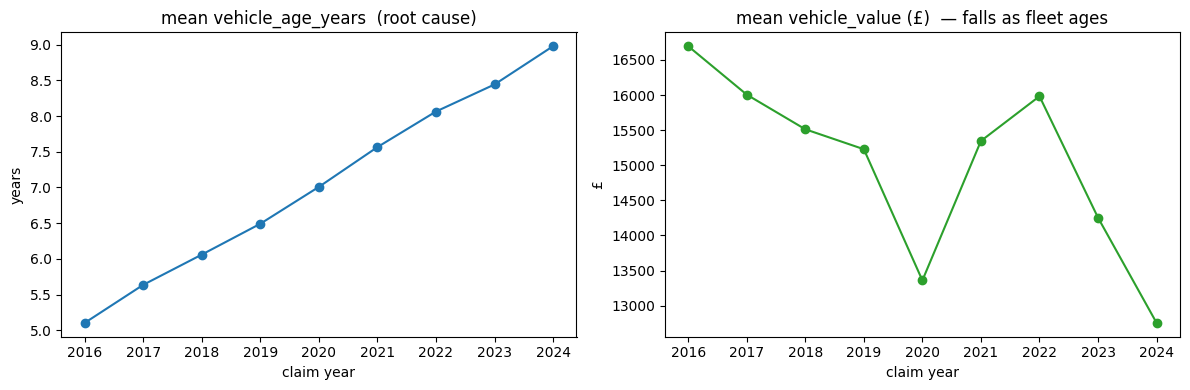

rtv correlations:
repair_to_value_ratio    1.000
vehicle_age_years        0.557
vehicle_value           -0.442
Name: repair_to_value_ratio, dtype: float64


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(by_year.index, by_year["age_mean"], "o-")
ax[0].set_title("mean vehicle_age_years  (root cause)")
ax[0].set_xlabel("claim year"); ax[0].set_ylabel("years")
ax[1].plot(by_year.index, by_year["veh_value"], "o-", color="C2")
ax[1].set_title("mean vehicle_value (£)  — falls as fleet ages")
ax[1].set_xlabel("claim year"); ax[1].set_ylabel("£")
plt.tight_layout(); plt.show()

print("rtv correlations:")
print(df[["repair_to_value_ratio", "vehicle_age_years", "vehicle_value"]]
      .corr()["repair_to_value_ratio"].round(3))


## 3 · Trace to the DGP — the fixed 2004 `manufacture_year` floor

`base_features.py` draws `manufacture_year` uniformly in
`[max(claim_year - 20, 2004), min(claim_year, 2024)]`. The lower bound is **pinned at 2004**.
So an early claim year (2016) can only contain cars up to ~12 years old (nothing older than
2004 exists), while a late claim year (2024) can contain cars up to 20 years old. The mean fleet
age therefore climbs *mechanically* with calendar time — not because the world changed, but
because of the fixed floor. Older fleet → lower value → higher rtv → higher true-TL rate.


In [7]:
floor = df.groupby("year").agg(
    mfr_min=("manufacture_year", "min"),
    mfr_max=("manufacture_year", "max"),
    age_min=("vehicle_age_years", "min"),
    age_max=("vehicle_age_years", "max"),
)
floor["age_span"] = floor["age_max"] - floor["age_min"]
print("manufacture_year floor stays at 2004 while the max advances -> age span widens:")
floor


manufacture_year floor stays at 2004 while the max advances -> age span widens:


,mfr_min,mfr_max,age_min,age_max,age_span
year,,,,,
2016,2004,2016,0,12,12
2017,2004,2017,0,13,13
2018,2004,2018,0,14,14
2019,2004,2019,0,15,15
2020,2004,2020,0,16,16
2021,2004,2021,0,17,17
2022,2004,2022,0,18,18
2023,2004,2023,0,19,19
2024,2004,2024,0,20,20


## 4 · Implications for SFP detection

- **Scrap-rate inflation is a confounded symptom.** Part of the v1→v2a→v3a scrap rise reflects
  this genuine upward drift in the true total-loss rate (feature drift), **not** the SFP loop.
  Reading scrap inflation as SFP would over-state the loop.
- **The clean signal is the within-window contaminated−oracle precision gap** (0.002 → 0.008 →
  0.016), which is measured on a *fixed* window and so is not moved by cross-year base-rate drift.
- **The oracle-precision *level* is not comparable across versions** because v1's OOT window
  (2021, true rate ≈16.6%) and the 2024 windows (≈22.1%) sit at different base rates.
- This is the synthetic analogue of the real-data confounds in `problem.md` §2.5 (#6 channel mix,
  #8 enrichment refresh, #10 preprocessing divergence): score/scrap drift must be **decomposed**,
  not read directly as SFP.

**Open item (not actioned here):** the 2004 manufacture-year floor is a generation artifact. If a
flat cross-year true-TL rate is wanted, `base_features.py` would need the floor to track
`claim_year - 20` without the hard 2004 clamp (or the enrichment value model to be age-detrended).
Left as a DGP decision — this notebook only diagnoses it.
